In [1]:
%%html
<style>
    h1 {color:purple}
    h2 {color:purple}
    h3 {color:#0099ff}
    hr {
        border: 0;
        height: 3px;
        background: #333;
        background-image: linear-gradient(to right, limegreen, deepskyblue, limegreen);
    }
</style>

# Outline
0. Part 0 — Intro/Setup
1. Part 1 — OpenAI Python APIs
2. **Part 2 — OpenAI Agents SDK**
   * 02-00. Agents SDK Introduction: building blocks, ReAct pattern
   * 02-01. Single Agent System — Python Tutor: `Agent`, `Runner.run()`, `RunResult`
   * 02-02. Conversation State in Agents: `previous_response_id`, `SQLiteSession`, `conversation_id`, `result.to_input_list()`
   * 02-03. Streaming Text and Events: `Runner.run_streamed()`, `StreamEvent`, `run_item_stream_event`
   * 02-04. Python Tutor with a Model-Backed Input Guardrail: `@input_guardrail`, `GuardrailFunctionOutput`, `InputGuardrailTripwireTriggered`
   * **02-05. Tools**
      * 02-05-00. Tools Overview: hosted, local, and custom tool taxonomy
      * 02-05-01. Financial Research Agent with a Custom Tool: `@function_tool`, hosted and custom tools
      * 02-05-02. Image Generation and Editing with `ImageGenerationTool`
      * 02-05-03. Multi-Agent Deitel Book Concierge: `FileSearchTool`, RAG, vector stores, handoffs
      * 02-05-04. **Code Interpreter Tool: `CodeInterpreterTool`, hosted container**
      * 02-05-05. Hosted MCP — Weather and Geocoding: `MCPServerStreamableHttp`, MCP authentication
      * 02-05-06. Local MCP — SQLite Database: `MCPServerStdio`
      * 02-05-07. AccuWeather Agent with `ComputerTool`: `AsyncComputer`, Playwright, `LocalBrowserComputer`
      * 02-05-08. `ShellTool` Folder Inspector: custom executor, human-in-the-loop approval
      * 02-05-09. Local LLM via LiteLLM and Ollama: `LitellmModel`
      * 02-05-10. Python Code Tutor with Dynamic Instructions: callable instructions, `RunContextWrapper`, typed context
3. Part 3 — Codex App
4. Part 4 — Wrap-Up and Additional References

---


# Creating Agents with the OpenAI Agents SDK
---
# Code Interpreter Tool

* `CodeInterpreterTool` allows agents to write and execute Python 
    * OpenAI-hosted sandbox created on the fly or in advance
* Model decides code to write, executes it, and can auto-revise on errors
* Any generated files returned as container file citations in the result
---

## Imports and Constants

In [2]:
from pathlib import Path

from IPython.display import Image, Markdown, display
from openai import OpenAI
from agents import Agent, CodeInterpreterTool, ModelSettings, Runner, trace

OUTPUT_DIR = Path('resources') / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

client = OpenAI()

---

## Helper Function to Save Files Created in the Hosted Container
* Generated files come back as `container_file_citation` annotations in `result.new_items`
* Download artifacts promptly — hosted code-interpreter containers are ephemeral
    * Removed after 20 minutes of inactivity

In [3]:
def save_container_artifacts(result, prefix):
    """Download Code Interpreter output files and display any images."""
    paths = []
    seen_files = set()
    number = 1

    # CodeInterpreterTool creates files in an OpenAI-hosted container. 
    # When final answer cites a generated file, SDK exposes it as a
    # container_file_citation annotation in result.new_items.
    for item in result.new_items:
        raw_item = getattr(item, 'raw_item', None)

        # Different run items have different shapes. getattr keeps this loop
        # safe across messages, tool calls and other item types.
        for content_part in getattr(raw_item, 'content', []) or []:
            for annotation in getattr(content_part, 'annotations', []) or []:
                # skip annotations that are not generated container files
                if getattr(annotation, 'type', None) != 'container_file_citation':
                    continue

                # same file can be cited more than once in final output
                file_key = (annotation.container_id, annotation.file_id)
                
                if file_key not in seen_files:
                    seen_files.add(file_key) 

                # preserve generated file extension when possible
                suffix = Path(annotation.filename).suffix or '.bin'
                path = OUTPUT_DIR / f'{prefix}_{number}{suffix}'

                # download file bytes from hosted container
                data = client.containers.files.content.retrieve(
                    file_id=annotation.file_id, 
                    container_id=annotation.container_id
                )

                # save the file
                path.write_bytes(data.read())
                paths.append(path)
                number += 1

                # display image artifacts inline for immediate feedback
                if path.suffix.lower() in ('.png', '.jpg', '.jpeg'):
                    display(Image(filename=str(path), width=400))

    return paths


def display_code_interpreter_code(result):
    """Display Python code written by Code Interpreter tool calls."""
    code_blocks = []

    for item in result.new_items:
        raw_item = getattr(item, 'raw_item', None)

        if getattr(raw_item, 'type', None) == 'code_interpreter_call':
            code = getattr(raw_item, 'code', None)

            if code:
                code_blocks.append(f'```python\n{code}\n```')

    if code_blocks:
        display(Markdown('## Code Interpreter Generated Code\n\n' + '\n\n'.join(code_blocks)))
    else:
        display(Markdown('_No Code Interpreter code found in this result._'))

---
## Demo: Benchmark Python Implementations with Code Interpreter

* Compare a `for` loop, a list comprehension, and NumPy for the same computation
* Code Interpreter runs repeatable `timeit` measurements in the hosted sandbox
* The agent generates a bar chart and returns a Markdown table of results
* `ModelSettings(tool_choice='required')` forces the agent to use the tool rather than answering from training data

Benchmarked with `timeit.repeat` using 7 repeats × 3 runs each for summing squares from `0` to `999,999`.

| Method | Median time/run | Min time/run | Std. dev. | Speed vs. for loop |
|---|---:|---:|---:|---:|
| for loop | 52.47 ms | 50.15 ms | 1.55 ms | 1.00× |
| list comprehension | 58.49 ms | 50.98 ms | 7.09 ms | 0.90× |
| NumPy | 10.98 ms | 10.64 ms | 2.86 ms | 4.78× |

### Analysis

- **NumPy was fastest**, about **4.8× faster** than the plain Python `for` loop, despite including array allocation with `np.arange`.
- The **for loop slightly beat the list comprehension** in this run. Although list comprehensions are often faster for constructing lists, here they allocate a full intermediate list of 1,000,000 integers before summing, which adds overhead.
- NumPy benefits from vectorized operations implemented in optimized native code.

Saved chart: [benchmark.png](sandbox:/mnt/data/benchmark.png)

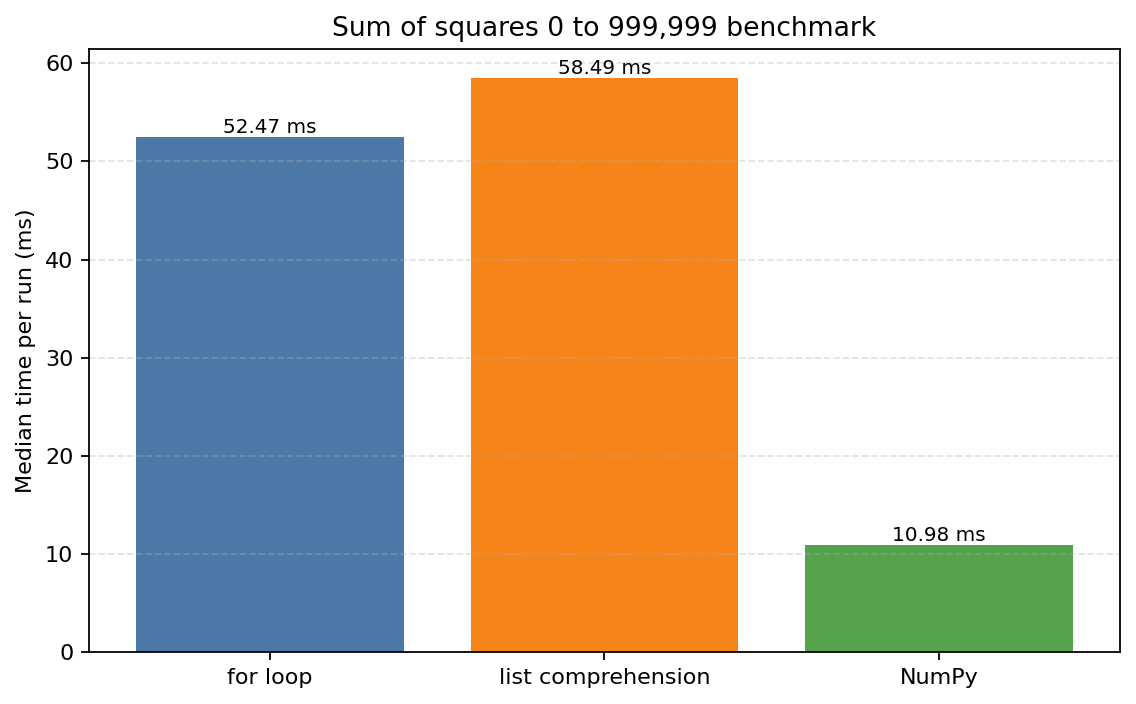

## Code Interpreter Generated Code

```python
import timeit, statistics, os, textwrap, math
import numpy as np
import matplotlib.pyplot as plt

N = 1_000_000

# Verify correctness
def for_loop():
    total = 0
    for i in range(N):
        total += i*i
    return total

def list_comp():
    return sum([i*i for i in range(N)])

def numpy_sum():
    arr = np.arange(N, dtype=np.int64)
    return np.sum(arr * arr)

expected = N*(N-1)*(2*N-1)//6
assert for_loop() == expected
assert list_comp() == expected
assert int(numpy_sum()) == expected

# Timeit with repeat. Number chosen for reasonable stability/runtime.
benchmarks = {
    "for loop": "for_loop()",
    "list comprehension": "list_comp()",
    "NumPy": "numpy_sum()",
}
setup = "from __main__ import for_loop, list_comp, numpy_sum"

results = {}
for name, stmt in benchmarks.items():
    # Use 7 repeats, 3 executions each for Python methods; NumPy too to include allocation cost.
    repeat = 7
    number = 3
    times = timeit.repeat(stmt=stmt, setup=setup, repeat=repeat, number=number, globals=globals())
    per_run = [t / number for t in times]
    results[name] = {
        "min": min(per_run),
        "median": statistics.median(per_run),
        "mean": statistics.mean(per_run),
        "stdev": statistics.stdev(per_run),
        "all": per_run,
    }

results

```

```python
# Create bar chart using median times
names = list(results.keys())
med_ms = [results[n]["median"] * 1000 for n in names]
colors = ["#4C78A8", "#F58518", "#54A24B"]

plt.figure(figsize=(7.2, 4.5), dpi=160)
bars = plt.bar(names, med_ms, color=colors)
plt.ylabel("Median time per run (ms)")
plt.title("Sum of squares 0 to 999,999 benchmark")
plt.grid(axis="y", linestyle="--", alpha=0.35)
for bar, val in zip(bars, med_ms):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.2f} ms",
             ha="center", va="bottom", fontsize=9)
plt.tight_layout()
out = "/mnt/data/benchmark.png"
plt.savefig(out, bbox_inches="tight")
plt.close()

# Compute speedups vs for loop and fastest
baseline = results["for loop"]["median"]
summary = []
for n in names:
    summary.append((n, results[n]["median"]*1000, results[n]["min"]*1000, results[n]["stdev"]*1000, baseline/results[n]["median"]))
out, summary

```

In [4]:
benchmark_agent = Agent(
    name='Python Benchmark Agent',
    model='gpt-5.5',
    instructions="""You benchmark Python implementations.
        Use Code Interpreter for all timing measurements.
        Return concise results.""",
    model_settings=ModelSettings(tool_choice='required'), # force tool use
    tools=[
        CodeInterpreterTool(
            tool_config={
                'type': 'code_interpreter',
                'container': {'type': 'auto'} # OpenAI creates hosted container automatically
            }
        )
    ]
)

prompt = """Use Code Interpreter to benchmark three ways to compute
the sum of squares from 0 to 999,999: a for loop, a list comprehension,
and NumPy. Use timeit for stable timing. Analyze the results, including
a Markdown table summary, and save a bar chart as benchmark.png."""

with trace('02-05-04-code-interpreter-benchmark'):
    result = await Runner.run(benchmark_agent, prompt)

display(Markdown(result.final_output))
save_container_artifacts(result, 'benchmark')
display_code_interpreter_code(result)

---

## Visualizing the Agent Workflow

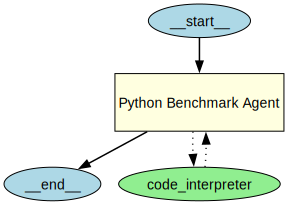

In [5]:
from agents.extensions.visualization import draw_graph
draw_graph(benchmark_agent, filename='agent_workflow.png')

---

## Documentation References

* [OpenAI Code Interpreter Guide](https://developers.openai.com/api/docs/guides/tools-code-interpreter)
* [OpenAI Agents SDK: Tools](https://openai.github.io/openai-agents-python/tools/)

---
&copy; 2026 by Deitel & Associates, Inc. All Rights Reserved.